# Toyota Kijang Innova Market Transition Analysis (2017–2026)
### From Diesel Ladder-Frame Dominance to Hybrid Monocoque Adoption in Indonesia's Premium MPV Segment

# 1. Introduction

## 1.1 Business Understanding

The Toyota Kijang Innova is not just a car in Indonesia, it is a cultural institution. For decades, it has consistently ranked as one of the best-selling vehicles in the country, serving everyone from families to government fleets, from rural adventurers to urban professionals. Its dominance in the premium MPV segment is virtually unchallenged.

But in November 2022, Toyota made a bold move. They introduced the **Innova Zenix**, a
completely new generation that ditched the traditional body-on-frame, rear-wheel-drive architecture that the Kijang lineage had carried since the 1970s, replacing it with Toyota's TNGA monocoque platform and front-wheel drive. More significantly, the Zenix dropped the diesel engine entirely, offering only gasoline and hybrid (HEV) powertrains.

What makes this story even more interesting is that Toyota **did not discontinue** the previous generation — the **Innova Reborn** (2016–present) — when the Zenix launched. Instead, both generations are sold simultaneously in the Indonesian market to this day. This parallel sales strategy suggests Toyota recognizes a real tension: a loyal base of diesel and ladder-frame advocates who are not yet ready to follow the new direction.

This dataset and analysis sit right at the heart of that tension. By examining GAIKINDO official wholesale data from 2017 to early 2026, we can trace exactly how the market has responded month by month to one of the most significant product transitions in Indonesian automotive history.

---

## 1.2 Problem Statement

This project addresses three interconnected questions:

1. **Transition Speed**: How quickly is the Indonesian market shifting from conventional
   powertrains (diesel and gasoline) toward hybrid, following the Zenix launch in late 2022?

2. **Chassis Reception**: How have consumers reacted to the fundamental engineering change —
   from a body-on-frame RWD platform (Reborn) to a TNGA monocoque FWD platform (Zenix)?
   Does the volume data suggest acceptance, resistance, or market segmentation?

3. **Crossover Projection**: Based on historical wholesale trends, when is the projected
   point where Zenix Hybrid wholesale volume will permanently surpass Innova Reborn Diesel —
   and is the total Innova segment growing or merely cannibalizing itself?

---

## 1.3 Analytical Approach

The analysis is structured in three phases:

- **Phase 1 — Exploratory Data Analysis (EDA)**: Understand volume trends, market share composition, seasonality patterns, and the pre/post-Zenix launch dynamics.

- **Phase 2 — Time-Series Forecasting**: Apply ARIMA-based models to forecast total Innova wholesale volume and hybrid market share through 2026–2027, with the goal of identifying the crossover point.

- **Phase 3 — Business Insights**: Translate the quantitative findings into actionable recommendations relevant to automotive manufacturers, dealers, and policy stakeholders in the context of Indonesia's EV and hybrid adoption landscape.

---

## 1.4 Evaluation Metrics

| Component | Metric | Description |
|---|---|---|
| EDA | Hybrid Adoption Rate (%) | Monthly hybrid share of total Innova wholesale |
| EDA | YoY Growth (%) | Year-over-year change per powertrain category |
| Forecasting | MAPE | Mean Absolute Percentage Error — primary accuracy metric |
| Forecasting | RMSE | Root Mean Square Error — penalizes large forecast deviations |
| Forecasting | MAE | Mean Absolute Error — raw error magnitude |
| Business | Crossover Year | Projected year hybrid permanently surpasses diesel |

---

## 1.5 Data Source

- **Source**: GAIKINDO (Gabungan Industri Kendaraan Bermotor Indonesia) Official Wholesale
  Reports, publicly available at [gaikindo.or.id](https://www.gaikindo.or.id)
- **Coverage**: January 2017 – March 2026
- **Scope**: Toyota Kijang Innova Reborn and Toyota Kijang Innova Zenix, all variants
- **Granularity**: Monthly wholesale units per variant
- **Processing**: PDF reports parsed, filtered, and structured by the author

> ⚠️ **Note**: Wholesale data (factory-to-dealer) is used as a proxy for consumer demand.
> It does not represent retail sales or end-consumer transactions directly. Short-term
> fluctuations may reflect dealer inventory cycles rather than pure market demand.


# 2. Library Importing

In [44]:
!pip install pmdarima

In [45]:
import numpy as np
import pandas as pd
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import pmdarima as pm
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error)
import warnings
warnings.filterwarnings("ignore")

Layout

In [46]:
pio.templates.default = "plotly_white"

# Brand color palette — mapped to each series
COLORS = {
    "Reborn Diesel":   "#C0392B",   # deep red   → legacy, conventional
    "Reborn Gasoline": "#E67E22",   # amber       → legacy, gasoline
    "Zenix Gasoline":  "#2980B9",   # steel blue  → new gen, gasoline
    "Zenix Hybrid":    "#27AE60",   # green       → new gen, clean energy
    "Total Innova":    "#8E44AD",   # purple      → aggregate
}

LAYOUT_DEFAULTS = dict(
    font=dict(family="Inter, Arial, sans-serif", size=13),
    title_font=dict(size=18, color="#2C3E50"),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1,
    ),
    margin=dict(t=80, b=60, l=60, r=40),
    hovermode="x unified",)

# 3. Data Understanding

## 3.1 Load data and previewing

In [47]:
df = pd.read_csv("/content/Innova_Wholesales_Data_2017_2026.csv")

In [48]:
df.head()

,Year,Month,Model,Fuel_Type,Transmission,Type,Wholesale,Sub-Type
0,2017,Jan,Reborn,Gasoline,Manual,G,779,NaN
1,2017,Feb,Reborn,Gasoline,Manual,G,1097,NaN
2,2017,Mar,Reborn,Gasoline,Manual,G,1498,NaN
3,2017,Apr,Reborn,Gasoline,Manual,G,1267,NaN
4,2017,May,Reborn,Gasoline,Manual,G,1168,NaN


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1437 entries, 0 to 1436
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Year          1437 non-null   int64 
 1   Month         1437 non-null   object
 2   Model         1437 non-null   object
 3   Fuel_Type     1437 non-null   object
 4   Transmission  1437 non-null   object
 5   Type          1437 non-null   object
 6   Wholesale     1437 non-null   int64 
 7   Sub-Type      564 non-null    object
dtypes: int64(2), object(6)
memory usage: 89.9+ KB


In [50]:
df.isna().sum()

,0
Year,0
Month,0
Model,0
Fuel_Type,0
Transmission,0
Type,0
Wholesale,0
Sub-Type,873


In [51]:
df.fillna("No subtype")

,Year,Month,Model,Fuel_Type,Transmission,Type,Wholesale,Sub-Type
0,2017,Jan,Reborn,Gasoline,Manual,G,779,No subtype
1,2017,Feb,Reborn,Gasoline,Manual,G,1097,No subtype
2,2017,Mar,Reborn,Gasoline,Manual,G,1498,No subtype
3,2017,Apr,Reborn,Gasoline,Manual,G,1267,No subtype
4,2017,May,Reborn,Gasoline,Manual,G,1168,No subtype
...,...,...,...,...,...,...,...,...
1432,2026,Feb,Zenix,Hybrid,Automatic,V,766,No subtype
1433,2026,Mar,Zenix,Hybrid,Automatic,V,470,No subtype
1434,2026,Jan,Zenix,Hybrid,Automatic,Q,891,No subtype
1435,2026,Feb,Zenix,Hybrid,Automatic,Q,821,No subtype


In [52]:
df.describe().round(2)

,Year,Wholesale
count,1437.00,1437.00
mean,2020.55,351.59
std,2.45,405.13
min,2017.00,0.00
25%,2018.00,27.00
50%,2020.00,212.00
75%,2022.00,559.00
max,2026.00,3105.00


In [53]:
df.duplicated().sum()

np.int64(0)

## 3.2 Summary

In [54]:
print("── Year Coverage ──")
print(df["Year"].value_counts().sort_index().to_string())

print("\n── Model Distribution ──")
print(df["Model"].value_counts().to_string())

print("\n── Fuel Type Distribution ──")
print(df["Fuel_Type"].value_counts().to_string())

print("\n── Transmission Distribution ──")
print(df["Transmission"].value_counts().to_string())

print("\n── Type (Variant Grade) Distribution ──")
print(df["Type"].value_counts().to_string())

print("\n── Volume per Series (Model × Fuel_Type) ──")
series_summary = (
    df.groupby(["Model", "Fuel_Type"])["Wholesale"]
    .sum()
    .reset_index()
    .sort_values("Wholesale", ascending=False)
    .assign(Share_Pct=lambda x: (x["Wholesale"] / x["Wholesale"].sum() * 100).round(2))
)
print(series_summary.to_string(index=False))

── Year Coverage ──
Year
2017    193
2018    167
2019    168
2020    216
2021    156
2022    216
2023    120
2024     96
2025     84
2026     21

── Model Distribution ──
Model
Reborn    1146
Zenix      291

── Fuel Type Distribution ──
Fuel_Type
Gasoline    691
Diesel      557
Hybrid      189

── Transmission Distribution ──
Transmission
Automatic    858
Manual       579

── Type (Variant Grade) Distribution ──
Type
G           517
V           437
Venturer    300
Q           183

── Volume per Series (Model × Fuel_Type) ──
 Model Fuel_Type  Wholesale  Share_Pct
Reborn    Diesel     230541      45.63
Reborn  Gasoline     149620      29.61
 Zenix    Hybrid      86743      17.17
 Zenix  Gasoline      38335       7.59


## 3.3 Date Engineering

In [55]:
MONTH_MAP = {
    "Jan": 1,  "Feb": 2,  "Mar": 3,  "Apr": 4,
    "May": 5,  "Jun": 6,  "Jul": 7,  "Aug": 8,
    "Sept": 9,  "Oct": 10, "Nov": 11, "Dec": 12,
}

df["Month_Num"] = df["Month"].map(MONTH_MAP)
df["Date"] = pd.to_datetime(
    dict(year=df["Year"], month=df["Month_Num"], day=1)
)

print(f"Date range: {df['Date'].min().strftime('%b %Y')} – {df['Date'].max().strftime('%b %Y')}")

Date range: Jan 2017 – Mar 2026


## 3.4 Mapping Chassis and ERA

In [56]:
CHASSIS_MAP = {
    "Reborn": "Ladder Frame RWD",
    "Zenix":  "Monocoque FWD",
}

df["Chassis"] = df["Model"].map(CHASSIS_MAP)

print("── Chassis Mapping ──")
print(df["Chassis"].value_counts().to_string())

── Chassis Mapping ──
Chassis
Ladder Frame RWD    1146
Monocoque FWD        291


In [57]:
df["Era"] = df["Date"].apply(
    lambda d: "Post-Zenix" if d >= pd.Timestamp("2022-11-01") else "Pre-Zenix"
)

print("── Era Split ──")
print(
    df.groupby("Era")["Wholesale"]
    .agg(
        Months="count",
        Total_Units="sum",
    )
    .assign(Avg_Monthly=lambda x: (x["Total_Units"] / x["Months"]).round(0))
    .to_string()
)

── Era Split ──
            Months  Total_Units  Avg_Monthly
Era                                         
Post-Zenix     357       214297        600.0
Pre-Zenix     1080       290942        269.0


In [58]:
df["Series"] = df["Model"] + " " + df["Fuel_Type"]

print("── Series Labels ──")
print(df["Series"].value_counts().to_string())

── Series Labels ──
Series
Reborn Gasoline    589
Reborn Diesel      557
Zenix Hybrid       189
Zenix Gasoline     102


In [59]:
df.to_csv("Innova_Wholesales_Enriched.csv", index=False)

# 4. Explanatory Data Analysis

In [60]:
df_enriched = pd.read_csv("Innova_Wholesales_Enriched.csv", parse_dates=["Date"])

monthly_series = (
    df_enriched.groupby(["Date", "Series", "Model", "Fuel_Type", "Chassis", "Era"])["Wholesale"]
    .sum()
    .reset_index()
    .sort_values("Date")
)

# Annual aggregated by Series
annual_series = (
    df_enriched.groupby(["Year", "Series", "Model", "Fuel_Type", "Chassis"])["Wholesale"]
    .sum()
    .reset_index()
    .sort_values("Year")
)

# Monthly total Innova (all series combined)
monthly_total = (
    df_enriched.groupby("Date")["Wholesale"]
    .sum()
    .reset_index()
    .rename(columns={"Wholesale": "Total"})
    .sort_values("Date")
)

## 4.1 Total Monthly Wholesale — All Innova

In [61]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=monthly_total["Date"],
    y=monthly_total["Total"],
    mode="lines+markers",
    name="Total Innova",
    line=dict(color=COLORS["Total Innova"], width=2.5),
    marker=dict(size=4),
    fill="tozeroy",
    fillcolor="rgba(142, 68, 173, 0.08)",
))

events = {
    "COVID-19 Lockdown": pd.Timestamp("2020-04-01"),
    "Zenix Launch":      pd.Timestamp("2022-11-01"),
}
for label, date in events.items():
    fig.add_vline(
        x=date.timestamp() * 1000,   # ✅ convert to milliseconds (Plotly requirement)
        line_dash="dash",
        line_color="gray",
        line_width=1.5,
        annotation_text=label,
        annotation_position="top",
        annotation_font_size=11,
    )

fig.update_layout(
    **LAYOUT_DEFAULTS,
    title="Total Toyota Kijang Innova Monthly Wholesale (2017–2026)",
    xaxis_title="Month",
    yaxis_title="Units Sold",
)
fig.show()

# 4.2 Monthly Wholesale by Series (Line Chart)

In [62]:
fig = go.Figure()

for series, color in COLORS.items():
    if series == "Total Innova":
        continue
    subset = monthly_series[monthly_series["Series"] == series]
    if subset.empty:
        continue
    fig.add_trace(go.Scatter(
        x=subset["Date"],
        y=subset["Wholesale"],
        mode="lines",
        name=series,
        line=dict(color=color, width=2),
        hovertemplate="%{y:,.0f} units<extra>" + series + "</extra>",
    ))

# ✅ FIXED
fig.add_vline(
    x=pd.Timestamp("2022-11-01").timestamp() * 1000,
    line_dash="dash", line_color="gray", line_width=1.5,
    annotation_text="Zenix Launch",
    annotation_position="top",
    annotation_font_size=11,
)

fig.update_layout(
    **LAYOUT_DEFAULTS,
    title="Monthly Wholesale by Powertrain Series (2017–2026)",
    xaxis_title="Month",
    yaxis_title="Units Sold",
)
fig.show()

# 4.3 Annual Wholesale — Stacked Bar

In [63]:
fig = go.Figure()

for series, color in COLORS.items():
    if series == "Total Innova":
        continue
    subset = annual_series[annual_series["Series"] == series]
    if subset.empty:
        continue
    fig.add_trace(go.Bar(
        x=subset["Year"],
        y=subset["Wholesale"],
        name=series,
        marker_color=color,
        hovertemplate="%{y:,.0f} units<extra>" + series + "</extra>",
    ))

fig.update_layout(
    **LAYOUT_DEFAULTS,
    title="Annual Wholesale by Powertrain Series (2017–2026)",
    xaxis_title="Year",
    yaxis_title="Units Sold",
    barmode="stack",
    xaxis=dict(tickmode="linear", dtick=1),
)
fig.show()

# 4.4 Fuel Share Annually

In [64]:
fuel_annual = (
    df_enriched.groupby(["Year", "Fuel_Type"])["Wholesale"]
    .sum()
    .reset_index()
)
fuel_annual["Share"] = fuel_annual.groupby("Year")["Wholesale"].transform(
    lambda x: x / x.sum() * 100
)

FUEL_COLORS = {
    "Diesel":   COLORS["Reborn Diesel"],
    "Gasoline": COLORS["Reborn Gasoline"],
    "Hybrid":   COLORS["Zenix Hybrid"],
}

fig = go.Figure()

for fuel, color in FUEL_COLORS.items():
    subset = fuel_annual[fuel_annual["Fuel_Type"] == fuel]
    fig.add_trace(go.Bar(
        x=subset["Year"],
        y=subset["Share"],
        name=fuel,
        marker_color=color,
        hovertemplate="%{y:.1f}%<extra>" + fuel + "</extra>",
    ))

fig.update_layout(
    **LAYOUT_DEFAULTS,
    title="Fuel Type Market Share Within Innova Segment (% per Year)",
    xaxis_title="Year",
    yaxis_title="Market Share (%)",
    barmode="relative",
    yaxis=dict(ticksuffix="%", range=[0, 100]),
    xaxis=dict(tickmode="linear", dtick=1),
)
fig.show()

## 4.5 Chassis Adoption rate

In [65]:
chassis_annual = (
    df_enriched.groupby(["Year", "Chassis"])["Wholesale"]
    .sum()
    .reset_index()
)
chassis_annual["Share"] = chassis_annual.groupby("Year")["Wholesale"].transform(
    lambda x: x / x.sum() * 100
)

CHASSIS_COLORS = {
    "Ladder Frame RWD": "#C0392B",
    "Monocoque FWD":    "#27AE60",
}

fig = go.Figure()

for chassis, color in CHASSIS_COLORS.items():
    subset = chassis_annual[chassis_annual["Chassis"] == chassis]
    fig.add_trace(go.Bar(
        x=subset["Year"],
        y=subset["Share"],
        name=chassis,
        marker_color=color,
        hovertemplate="%{y:.1f}%<extra>" + chassis + "</extra>",
    ))

fig.update_layout(
    **LAYOUT_DEFAULTS,
    title="Platform Share: Ladder Frame RWD vs Monocoque FWD (% per Year)",
    xaxis_title="Year",
    yaxis_title="Market Share (%)",
    barmode="relative",
    yaxis=dict(ticksuffix="%", range=[0, 100]),
    xaxis=dict(tickmode="linear", dtick=1),
)
fig.show()

## 4.6 Hybrid Adoption rate

In [66]:
hybrid_monthly = (
    df_enriched.groupby(["Date", "Fuel_Type"])["Wholesale"]
    .sum()
    .reset_index()
)
total_monthly_fuel = hybrid_monthly.groupby("Date")["Wholesale"].transform("sum")
hybrid_monthly["Share"] = hybrid_monthly["Wholesale"] / total_monthly_fuel * 100

hybrid_only = hybrid_monthly[hybrid_monthly["Fuel_Type"] == "Hybrid"].copy()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=hybrid_only["Date"],
    y=hybrid_only["Share"],
    mode="lines+markers",
    name="Hybrid Share",
    line=dict(color=COLORS["Zenix Hybrid"], width=2.5),
    fill="tozeroy",
    fillcolor="rgba(39, 174, 96, 0.1)",
    hovertemplate="%{y:.1f}%<extra>Hybrid Share</extra>",
))
fig.add_vline(
    x=pd.Timestamp("2022-11-01").timestamp() * 1000,
    line_dash="dash", line_color="gray", line_width=1.5,
    annotation_text="Zenix Launch",
    annotation_position="top",
    annotation_font_size=11,
)

fig.update_layout(
    **LAYOUT_DEFAULTS,
    title="Monthly Hybrid Adoption Rate Within Innova Segment (2022–2026)",
    xaxis_title="Month",
    yaxis_title="Hybrid Share (%)",
    yaxis=dict(ticksuffix="%"),
)
fig.show()

## 4.7 Heatmap (Seasonality)

In [70]:
pivot_total = (
    df_enriched.groupby(["Year", "Month_Num"])["Wholesale"]
    .sum()
    .reset_index()
    .pivot(index="Year", columns="Month_Num", values="Wholesale")
)
pivot_total.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                        "Jul","Aug","Sept","Oct","Nov","Dec"]

fig = go.Figure(data=go.Heatmap(
    z=pivot_total.values,
    x=pivot_total.columns.tolist(),
    y=pivot_total.index.tolist(),
    colorscale="Blues",
    hoverongaps=False,
    hovertemplate="Year: %{y}<br>Month: %{x}<br>Units: %{z:,.0f}<extra></extra>",
    colorbar=dict(title="Units"),
))

fig.update_layout(
    **LAYOUT_DEFAULTS,
    title="Total Innova Wholesales Heatmap — Seasonality by Year & Month",
    xaxis_title="Month",
    yaxis_title="Year",
    yaxis=dict(tickmode="linear", dtick=1),
)
fig.show()

# 4.8 Reborn Diesel vs Zenix Hybrid — Head to Head

In [72]:
h2h = monthly_series[
    monthly_series["Series"].isin(["Reborn Diesel", "Zenix Hybrid"])
].copy()

fig = go.Figure()

for series, color in [("Reborn Diesel", COLORS["Reborn Diesel"]),
                       ("Zenix Hybrid",  COLORS["Zenix Hybrid"])]:
    subset = h2h[h2h["Series"] == series]
    fig.add_trace(go.Scatter(
        x=subset["Date"],
        y=subset["Wholesale"],
        mode="lines",
        name=series,
        line=dict(color=color, width=2.5),
        hovertemplate="%{y:,.0f} units<extra>" + series + "</extra>",
    ))

def vline_date(fig, date_str, label):
    fig.add_vline(
        x=pd.Timestamp(date_str).timestamp() * 1000,
        line_dash="dash", line_color="gray", line_width=1.5,
        annotation_text=label,
        annotation_position="top",
        annotation_font_size=11,
    )

fig.update_layout(
    **LAYOUT_DEFAULTS,
    title="Head-to-Head: Reborn Diesel vs Zenix Hybrid Monthly Wholesale",
    xaxis_title="Month",
    yaxis_title="Units Sold",
)
fig.show()

# 4.9 YoY Growth per Fuel Type

In [74]:
yoy = (
    df_enriched.groupby(["Year", "Fuel_Type"])["Wholesale"]
    .sum()
    .reset_index()
)
yoy["YoY_Growth"] = yoy.groupby("Fuel_Type")["Wholesale"].pct_change() * 100
yoy["YoY_Label"]  = yoy["YoY_Growth"].apply(
    lambda x: f"{x:.1f}%" if pd.notna(x) else ""
)

fig = px.bar(
    yoy[yoy["Year"] > 2017],
    x="Year",
    y="YoY_Growth",
    color="Fuel_Type",
    barmode="group",
    color_discrete_map=FUEL_COLORS,
    text="YoY_Label",
    title="Year-over-Year Growth (%) by Fuel Type",
    labels={"YoY_Growth": "YoY Growth (%)", "Year": "Year"},
)

fig.update_traces(
    textposition="outside",
    texttemplate="%{text}",
    cliponaxis=False,
)

fig.update_layout(
    **LAYOUT_DEFAULTS,
    yaxis=dict(ticksuffix="%", zeroline=True, zerolinecolor="gray"),
    xaxis=dict(tickmode="linear", dtick=1),
    uniformtext_minsize=8,
    uniformtext_mode="hide",
)
fig.show()

## 4.10 Pre vs Post Zenix — Box Plot Distribution

In [75]:
fig = px.box(
    monthly_series,
    x="Series",
    y="Wholesale",
    color="Era",
    color_discrete_map={
        "Pre-Zenix":  "#95A5A6",
        "Post-Zenix": "#2ECC71",
    },
    points="all",
    title="Monthly Wholesale Distribution — Pre vs Post Zenix Launch",
    labels={"Wholesale": "Monthly Units", "Series": "Series"},
)
fig.update_layout(
    **LAYOUT_DEFAULTS,
    yaxis_title="Monthly Units",
)
fig.show()


# 5. Data Preparation for Time-Series Forecasting

## 5.1 Build Target Series
***We will forecast 3 series:***

(A) Total Innova monthly wholesale

(B) Zenix Hybrid monthly wholesale

(C) Reborn Diesel monthly wholesale

In [76]:
def build_monthly_ts(df, filter_col=None, filter_val=None):
    """
    Aggregate wholesale to monthly frequency.
    If filter_col and filter_val provided, filter first.
    Returns a DatetimeIndex Series sorted by date.
    """
    if filter_col and filter_val:
        df = df[df[filter_col] == filter_val]
    ts = (
        df.groupby("Date")["Wholesale"]
        .sum()
        .sort_index()
        .asfreq("MS")          # Monthly Start frequency
        .fillna(0)
    )
    return ts

ts_total         = build_monthly_ts(df_enriched)
ts_zenix_hybrid  = build_monthly_ts(df_enriched, "Series", "Zenix Hybrid")
ts_reborn_diesel = build_monthly_ts(df_enriched, "Series", "Reborn Diesel")

print("── Series Summary ──")
for name, ts in [("Total Innova", ts_total),
                  ("Zenix Hybrid", ts_zenix_hybrid),
                  ("Reborn Diesel", ts_reborn_diesel)]:
    print(f"\n  {name}")
    print(f"    Period : {ts.index[0].strftime('%b %Y')} – {ts.index[-1].strftime('%b %Y')}")
    print(f"    Length : {len(ts)} months")
    print(f"    Mean   : {ts.mean():,.0f} units/month")
    print(f"    Max    : {ts.max():,.0f} | Min: {ts.min():,.0f}")

── Series Summary ──

  Total Innova
    Period : Jan 2017 – Mar 2026
    Length : 111 months
    Mean   : 4,552 units/month
    Max    : 8,841 | Min: 186

  Zenix Hybrid
    Period : Jan 2022 – Mar 2026
    Length : 51 months
    Mean   : 1,701 units/month
    Max    : 3,768 | Min: 0

  Reborn Diesel
    Period : Jan 2017 – Mar 2026
    Length : 111 months
    Mean   : 2,077 units/month
    Max    : 5,276 | Min: 74


## 5.2 Test-train split

In [77]:
SPLIT_DATE = "2025-01-01"

def train_test_split_ts(ts, split_date=SPLIT_DATE):
    train = ts[ts.index < split_date]
    test  = ts[ts.index >= split_date]
    return train, test

train_total,  test_total  = train_test_split_ts(ts_total)
train_zenix,  test_zenix  = train_test_split_ts(ts_zenix_hybrid)
train_reborn, test_reborn = train_test_split_ts(ts_reborn_diesel)

print("── Train / Test Split ──")
for name, train, test in [
    ("Total Innova",  train_total,  test_total),
    ("Zenix Hybrid",  train_zenix,  test_zenix),
    ("Reborn Diesel", train_reborn, test_reborn),
]:
    print(f"\n  {name}")
    print(f"    Train: {train.index[0].strftime('%b %Y')} – "
          f"{train.index[-1].strftime('%b %Y')} ({len(train)} months)")
    print(f"    Test : {test.index[0].strftime('%b %Y')} – "
          f"{test.index[-1].strftime('%b %Y')} ({len(test)} months)")

── Train / Test Split ──

  Total Innova
    Train: Jan 2017 – Dec 2024 (96 months)
    Test : Jan 2025 – Mar 2026 (15 months)

  Zenix Hybrid
    Train: Jan 2022 – Dec 2024 (36 months)
    Test : Jan 2025 – Mar 2026 (15 months)

  Reborn Diesel
    Train: Jan 2017 – Dec 2024 (96 months)
    Test : Jan 2025 – Mar 2026 (15 months)


## 5.3 Stationary Test

In [78]:
def stationarity_test(ts, name):
    print(f"\n── {name} ──")

    # ADF
    adf_result  = adfuller(ts.dropna(), autolag="AIC")
    adf_stat, adf_p = adf_result[0], adf_result[1]

    # KPSS
    kpss_result = kpss(ts.dropna(), regression="c", nlags="auto")
    kpss_stat, kpss_p = kpss_result[0], kpss_result[1]

    print(f"  ADF  Statistic: {adf_stat:.4f}  | p-value: {adf_p:.4f}  "
          f"→ {'✅ Stationary' if adf_p < 0.05 else '⚠️  Non-Stationary'}")
    print(f"  KPSS Statistic: {kpss_stat:.4f}  | p-value: {kpss_p:.4f}  "
          f"→ {'✅ Stationary' if kpss_p > 0.05 else '⚠️  Non-Stationary'}")

stationarity_test(train_total,  "Total Innova")
stationarity_test(train_zenix,  "Zenix Hybrid")
stationarity_test(train_reborn, "Reborn Diesel")


── Total Innova ──
  ADF  Statistic: -3.5492  | p-value: 0.0068  → ✅ Stationary
  KPSS Statistic: 0.2589  | p-value: 0.1000  → ✅ Stationary

── Zenix Hybrid ──
  ADF  Statistic: -1.7989  | p-value: 0.3810  → ⚠️  Non-Stationary
  KPSS Statistic: 0.6055  | p-value: 0.0221  → ⚠️  Non-Stationary

── Reborn Diesel ──
  ADF  Statistic: -5.0922  | p-value: 0.0000  → ✅ Stationary
  KPSS Statistic: 0.3271  | p-value: 0.1000  → ✅ Stationary


## 5.3 Seasonal Decomposition

In [79]:
from statsmodels.tsa.seasonal import seasonal_decompose

def plot_decomposition(ts, name, color):
    decomp = seasonal_decompose(ts.dropna(), model="additive", period=12)

    fig = make_subplots(
        rows=4, cols=1,
        subplot_titles=["Observed", "Trend", "Seasonal", "Residual"],
        shared_xaxes=True,
        vertical_spacing=0.08,
    )

    components = [
        decomp.observed,
        decomp.trend,
        decomp.seasonal,
        decomp.resid,
    ]

    for i, comp in enumerate(components, start=1):
        fig.add_trace(
            go.Scatter(
                x=comp.index,
                y=comp.values,
                mode="lines",
                line=dict(color=color, width=1.8),
                showlegend=False,
            ),
            row=i, col=1,
        )

    fig.update_layout(
        **LAYOUT_DEFAULTS,
        title=f"Seasonal Decomposition — {name}",
        height=700,
    )
    fig.show()

plot_decomposition(train_total,  "Total Innova",  COLORS["Total Innova"])
plot_decomposition(train_zenix,  "Zenix Hybrid",  COLORS["Zenix Hybrid"])
plot_decomposition(train_reborn, "Reborn Diesel", COLORS["Reborn Diesel"])

## 5.5 ACF PACF Plot

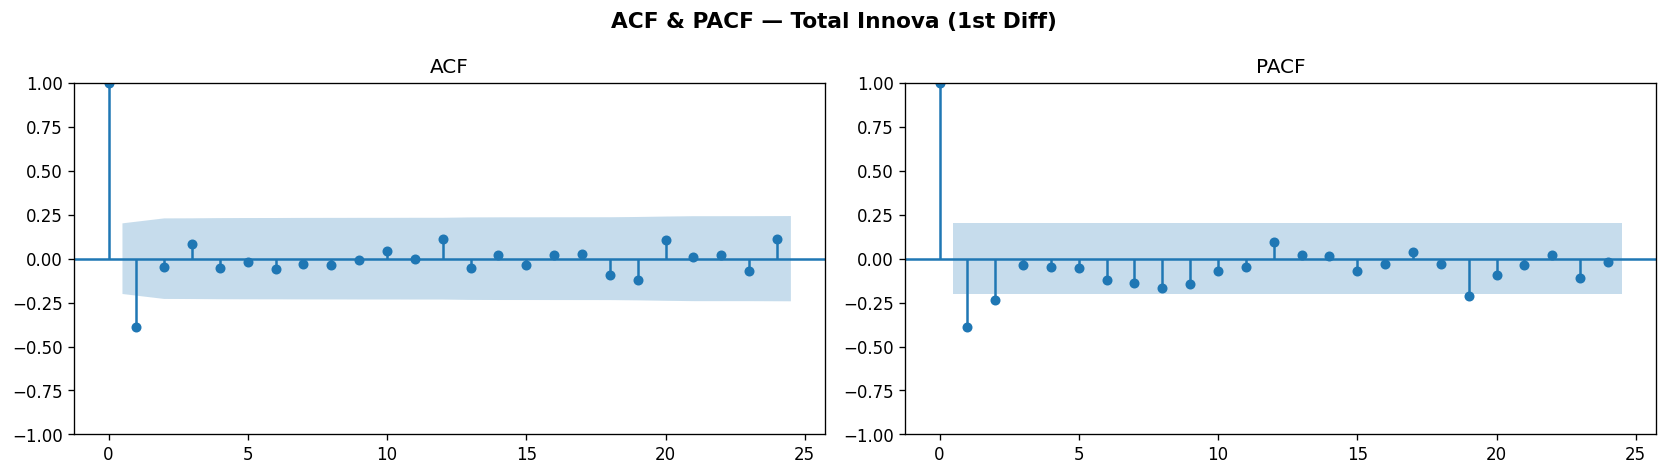

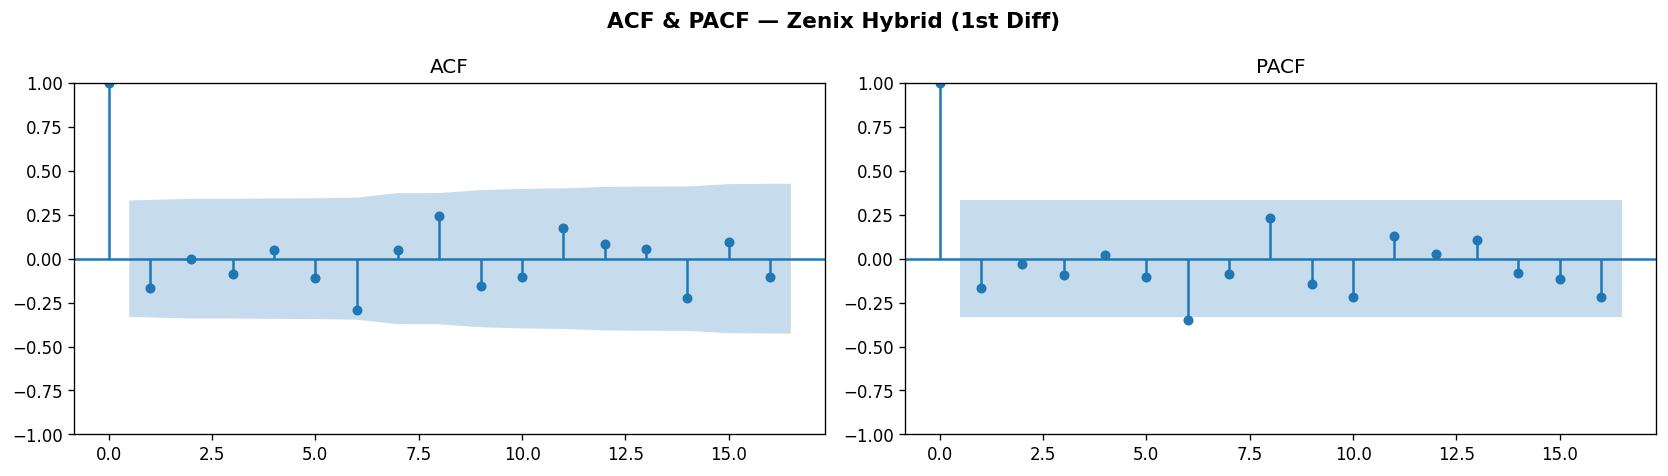

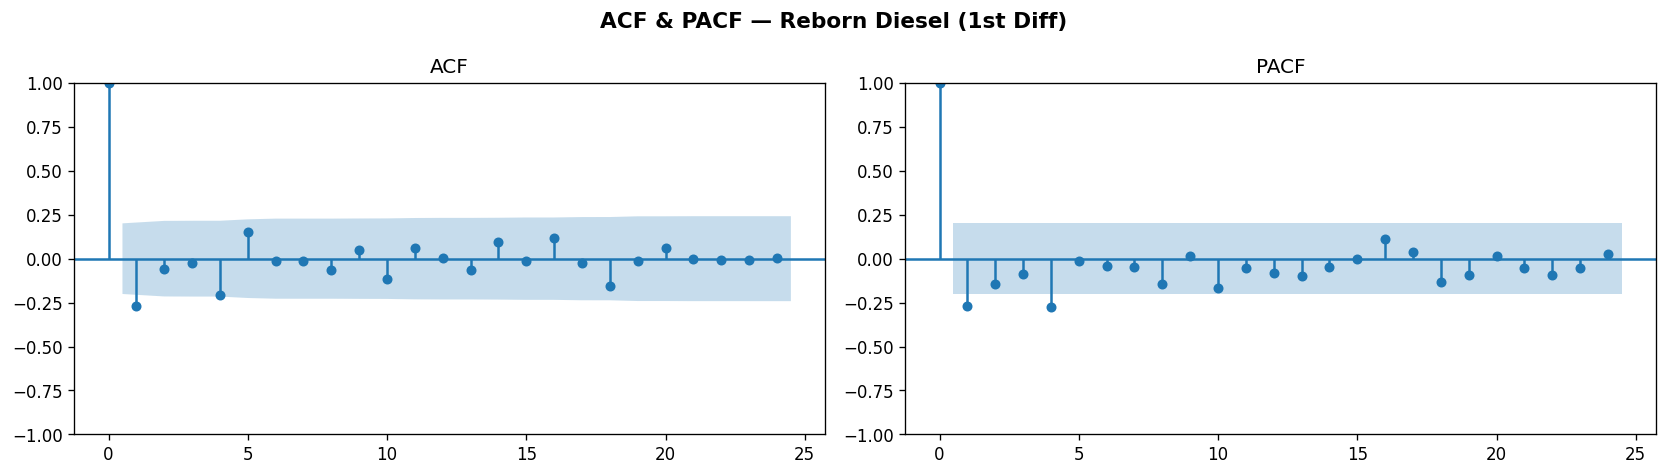

In [82]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

def plot_acf_pacf(ts, name, lags=24):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"ACF & PACF — {name}", fontsize=13, fontweight="bold")

    plot_acf(ts.dropna(),  lags=lags, ax=axes[0], title="ACF")
    plot_pacf(ts.dropna(), lags=lags, ax=axes[1], title="PACF", method="ywm")

    plt.tight_layout()
    plt.show()

# Apply first-difference if non-stationary from 5.3
plot_acf_pacf(train_total.diff().dropna(),  "Total Innova (1st Diff)")
# Reduced lags for Zenix Hybrid due to shorter series length
plot_acf_pacf(train_zenix.diff().dropna(),  "Zenix Hybrid (1st Diff)", lags=16)
plot_acf_pacf(train_reborn.diff().dropna(), "Reborn Diesel (1st Diff)")

## 5.6 Save prepared csv

In [81]:
ts_df = pd.DataFrame({
    "Date":         ts_total.index,
    "Total_Innova": ts_total.values,
    "Zenix_Hybrid": ts_zenix_hybrid.reindex(ts_total.index, fill_value=0).values,
    "Reborn_Diesel":ts_reborn_diesel.reindex(ts_total.index, fill_value=0).values,
})
ts_df["Hybrid_Share"]  = ts_df["Zenix_Hybrid"]  / ts_df["Total_Innova"] * 100
ts_df["Diesel_Share"]  = ts_df["Reborn_Diesel"] / ts_df["Total_Innova"] * 100
ts_df = ts_df.round(2)

ts_df.to_csv("Innova_TimeSeries_Prepared.csv", index=False)

# 6. Time series using ARIMA

In [83]:
from pmdarima import auto_arima

def find_best_arima(train, name):
    print(f"\n🔍 Searching best SARIMA order for: {name}")
    model = auto_arima(
        train,
        m=12,                    # seasonal period = 12 months
        d=None,                  # auto-detect differencing order
        D=None,                  # auto-detect seasonal differencing
        start_p=0, max_p=3,
        start_q=0, max_q=3,
        start_P=0, max_P=2,
        start_Q=0, max_Q=2,
        information_criterion="aic",
        stepwise=True,
        seasonal=True,
        error_action="ignore",
        suppress_warnings=True,
        trace=True,              # print AIC per candidate
    )
    print(f"\n  ✅ Best order  : {model.order}")
    print(f"     Seasonal   : {model.seasonal_order}")
    print(f"     AIC        : {model.aic():.2f}")
    return model

model_total  = find_best_arima(train_total,  "Total Innova")
model_zenix  = find_best_arima(train_zenix,  "Zenix Hybrid")
model_reborn = find_best_arima(train_reborn, "Reborn Diesel")


🔍 Searching best SARIMA order for: Total Innova
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1694.852, Time=0.09 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1661.005, Time=0.34 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=1672.990, Time=0.65 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1899.972, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=1660.792, Time=0.12 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=1661.192, Time=0.99 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=1662.939, Time=1.77 sec
 ARIMA(2,0,0)(0,0,0)[12] intercept   : AIC=1658.365, Time=0.20 sec
 ARIMA(2,0,0)(1,0,0)[12] intercept   : AIC=1658.433, Time=0.49 sec
 ARIMA(2,0,0)(0,0,1)[12] intercept   : AIC=1658.845, Time=0.72 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=1660.430, Time=0.75 sec
 ARIMA(3,0,0)(0,0,0)[12] intercept   : AIC=1658.915, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[12] intercept   : AIC=1659.776, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   

## 6.2 Model Summary

In [85]:
print("\n═══════════════════════════════════════")
print("  SARIMA MODEL SUMMARY — TOTAL INNOVA")
print("═══════════════════════════════════════")
print(model_total.summary())

print("\n══════════════════════════════════════")
print("  SARIMA MODEL SUMMARY — ZENIX HYBRID")
print("══════════════════════════════════════")
print(model_zenix.summary())

print("\n═════════════════════════════════════════")
print("  SARIMA MODEL SUMMARY — REBORN DIESEL")
print("═════════════════════════════════════════")
print(model_reborn.summary())


═══════════════════════════════════════
  SARIMA MODEL SUMMARY — TOTAL INNOVA
═══════════════════════════════════════
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   96
Model:               SARIMAX(2, 0, 0)   Log Likelihood                -825.183
Date:                Mon, 20 Apr 2026   AIC                           1658.365
Time:                        13:59:40   BIC                           1668.623
Sample:                    01-01-2017   HQIC                          1662.511
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1538.6023    442.521      3.477      0.001     671.276    2405.928
ar.L1       

## 6.2 Residual Analysis

In [86]:
def plot_residuals(model, name, color):
    residuals = pd.Series(model.resid(), index=train_total.index[:len(model.resid())])

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=["Residuals Over Time", "Residual Distribution"],
    )

    # Residual line
    fig.add_trace(
        go.Scatter(
            x=residuals.index,
            y=residuals.values,
            mode="lines",
            line=dict(color=color, width=1.5),
            name="Residual",
            showlegend=False,
        ),
        row=1, col=1,
    )
    fig.add_hline(y=0, line_dash="dash", line_color="gray", row=1, col=1)

    # Histogram
    fig.add_trace(
        go.Histogram(
            x=residuals.values,
            nbinsx=30,
            marker_color=color,
            opacity=0.75,
            name="Distribution",
            showlegend=False,
        ),
        row=1, col=2,
    )

    fig.update_layout(
        **LAYOUT_DEFAULTS,
        title=f"Residual Diagnostics — {name}",
        height=380,
    )
    fig.show()

plot_residuals(model_total,  "Total Innova",  COLORS["Total Innova"])
plot_residuals(model_zenix,  "Zenix Hybrid",  COLORS["Zenix Hybrid"])
plot_residuals(model_reborn, "Reborn Diesel", COLORS["Reborn Diesel"])

## 6.4 Test Set Prediction (In-Sample Validation)

In [87]:
def evaluate_model(model, train, test, name):
    n_test = len(test)

    # Forecast on test horizon
    forecast_obj  = model.predict(n_periods=n_test, return_conf_int=True)
    forecast_vals = forecast_obj[0]
    conf_int      = forecast_obj[1]

    forecast_series = pd.Series(forecast_vals, index=test.index)
    lower           = pd.Series(conf_int[:, 0], index=test.index)
    upper           = pd.Series(conf_int[:, 1], index=test.index)

    # Metrics
    mae  = mean_absolute_error(test, forecast_vals)
    rmse = np.sqrt(mean_squared_error(test, forecast_vals))
    mape = mean_absolute_percentage_error(test, forecast_vals) * 100

    print(f"\n── {name} — Test Set Metrics ──")
    print(f"   MAE  : {mae:,.1f} units")
    print(f"   RMSE : {rmse:,.1f} units")
    print(f"   MAPE : {mape:.2f}%")

    return forecast_series, lower, upper, {"MAE": mae, "RMSE": rmse, "MAPE": mape}

fc_total,  lo_total,  hi_total,  met_total  = evaluate_model(
    model_total,  train_total,  test_total,  "Total Innova")
fc_zenix,  lo_zenix,  hi_zenix,  met_zenix  = evaluate_model(
    model_zenix,  train_zenix,  test_zenix,  "Zenix Hybrid")
fc_reborn, lo_reborn, hi_reborn, met_reborn = evaluate_model(
    model_reborn, train_reborn, test_reborn, "Reborn Diesel")


── Total Innova — Test Set Metrics ──
   MAE  : 714.8 units
   RMSE : 921.5 units
   MAPE : 13.46%

── Zenix Hybrid — Test Set Metrics ──
   MAE  : 249.5 units
   RMSE : 346.8 units
   MAPE : 14.78%

── Reborn Diesel — Test Set Metrics ──
   MAE  : 630.1 units
   RMSE : 904.0 units
   MAPE : 21.42%


##  6.5 Forecast vs Actual — Test Period Plot

In [88]:
def plot_forecast_vs_actual(train, test, forecast, lower, upper,
                             name, color, split_date=SPLIT_DATE):
    fig = go.Figure()

    # Train actuals
    fig.add_trace(go.Scatter(
        x=train.index, y=train.values,
        mode="lines", name="Train Actual",
        line=dict(color="#95A5A6", width=1.5),
    ))

    # Test actuals
    fig.add_trace(go.Scatter(
        x=test.index, y=test.values,
        mode="lines+markers", name="Test Actual",
        line=dict(color=color, width=2),
        marker=dict(size=6),
    ))

    # Forecast
    fig.add_trace(go.Scatter(
        x=forecast.index, y=forecast.values,
        mode="lines+markers", name="SARIMA Forecast",
        line=dict(color=color, width=2, dash="dash"),
        marker=dict(size=6, symbol="diamond"),
    ))

    # Confidence interval band
    fig.add_trace(go.Scatter(
        x=pd.concat([upper.rename("x"), lower.rename("x")[::-1]]).index,
        y=pd.concat([upper, lower[::-1]]).values,
        fill="toself",
        fillcolor=f"rgba{tuple(list(int(color.lstrip('#')[i:i+2], 16)
                    for i in (0,2,4)) + [0.15])}",
        line=dict(color="rgba(255,255,255,0)"),
        name="95% CI",
        showlegend=True,
    ))

    # Split line
    fig.add_vline(
        x=pd.Timestamp(split_date).timestamp() * 1000,
        line_dash="dash", line_color="gray", line_width=1.5,
        annotation_text="Train/Test Split",
        annotation_position="top",
    )

    fig.update_layout(
        **LAYOUT_DEFAULTS,
        title=f"SARIMA Forecast vs Actual — {name}",
        xaxis_title="Month",
        yaxis_title="Units Sold",
    )
    fig.show()

plot_forecast_vs_actual(
    train_total, test_total, fc_total, lo_total, hi_total,
    "Total Innova", COLORS["Total Innova"])

plot_forecast_vs_actual(
    train_zenix, test_zenix, fc_zenix, lo_zenix, hi_zenix,
    "Zenix Hybrid", COLORS["Zenix Hybrid"])

plot_forecast_vs_actual(
    train_reborn, test_reborn, fc_reborn, lo_reborn, hi_reborn,
    "Reborn Diesel", COLORS["Reborn Diesel"])

## 6.6 Future Forecast

In [89]:
FORECAST_HORIZON = 24

def refit_and_forecast(model, full_series, name, horizon=FORECAST_HORIZON):
    print(f"\n🔄 Refitting {name} on full series...")

    # Refit with same order on full data
    final_model = SARIMAX(
        full_series,
        order=model.order,
        seasonal_order=model.seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

    # Forecast
    forecast_obj = final_model.get_forecast(steps=horizon)
    forecast_mean = forecast_obj.predicted_mean
    conf_int      = forecast_obj.conf_int()

    # Build future date index
    last_date    = full_series.index[-1]
    future_index = pd.date_range(
        start=last_date + pd.DateOffset(months=1),
        periods=horizon,
        freq="MS",
    )
    forecast_mean.index = future_index
    conf_int.index      = future_index

    print(f"   ✅ Forecast horizon: {future_index[0].strftime('%b %Y')} – "
          f"{future_index[-1].strftime('%b %Y')}")

    return forecast_mean, conf_int, final_model

future_total,  ci_total,  fm_total  = refit_and_forecast(
    model_total,  ts_total,         "Total Innova")
future_zenix,  ci_zenix,  fm_zenix  = refit_and_forecast(
    model_zenix,  ts_zenix_hybrid,  "Zenix Hybrid")
future_reborn, ci_reborn, fm_reborn = refit_and_forecast(
    model_reborn, ts_reborn_diesel, "Reborn Diesel")


🔄 Refitting Total Innova on full series...
   ✅ Forecast horizon: Apr 2026 – Mar 2028

🔄 Refitting Zenix Hybrid on full series...
   ✅ Forecast horizon: Apr 2026 – Mar 2028

🔄 Refitting Reborn Diesel on full series...
   ✅ Forecast horizon: Apr 2026 – Mar 2028


In [90]:
def plot_full_forecast(historical, future_mean, conf_int,
                        name, color):
    lower = conf_int.iloc[:, 0]
    upper = conf_int.iloc[:, 1]

    fig = go.Figure()

    # Historical
    fig.add_trace(go.Scatter(
        x=historical.index, y=historical.values,
        mode="lines", name="Historical",
        line=dict(color="#95A5A6", width=1.8),
    ))

    # Future forecast
    fig.add_trace(go.Scatter(
        x=future_mean.index, y=future_mean.values,
        mode="lines+markers", name="Forecast",
        line=dict(color=color, width=2.5, dash="dash"),
        marker=dict(size=6, symbol="diamond"),
    ))

    # CI band
    fig.add_trace(go.Scatter(
        x=list(upper.index) + list(lower.index[::-1]),
        y=list(upper.values) + list(lower.values[::-1]),
        fill="toself",
        fillcolor=f"rgba{tuple(list(int(color.lstrip('#')[i:i+2], 16)
                    for i in (0,2,4)) + [0.15])}",
        line=dict(color="rgba(255,255,255,0)"),
        name="95% CI",
    ))

    # Forecast start line
    fig.add_vline(
        x=pd.Timestamp(historical.index[-1]).timestamp() * 1000,
        line_dash="dot", line_color="gray", line_width=1.5,
        annotation_text="Forecast Start",
        annotation_position="top",
    )

    fig.update_layout(
        **LAYOUT_DEFAULTS,
        title=f"SARIMA Full Forecast — {name} (2017–2028)",
        xaxis_title="Month",
        yaxis_title="Units Sold",
    )
    fig.show()

plot_full_forecast(ts_total,        future_total,  ci_total,
                   "Total Innova",  COLORS["Total Innova"])
plot_full_forecast(ts_zenix_hybrid, future_zenix,  ci_zenix,
                   "Zenix Hybrid",  COLORS["Zenix Hybrid"])
plot_full_forecast(ts_reborn_diesel,future_reborn, ci_reborn,
                   "Reborn Diesel", COLORS["Reborn Diesel"])

## 6.7 Crossover Point Detection

In [92]:
combined = pd.DataFrame({
    "Zenix_Hybrid":  pd.concat([ts_zenix_hybrid,  future_zenix]),
    "Reborn_Diesel": pd.concat([ts_reborn_diesel, future_reborn]),
})
combined["Is_Forecast"] = combined.index > ts_total.index[-1]
combined["Hybrid_Leads"] = combined["Zenix_Hybrid"] > combined["Reborn_Diesel"]

# Find first month where Hybrid leads AND stays ahead for 3+ consecutive months
crossover_date = None
streak = 0
for date, row in combined.iterrows():
    if row["Hybrid_Leads"]:
        streak += 1
        if streak >= 3 and crossover_date is None:
            crossover_date = date - pd.DateOffset(months=streak - 1)
    else:
        streak = 0

if crossover_date:
    print(f"\n🎯 Projected Crossover Point: {crossover_date.strftime('%B %Y')}")
    print(f"   → From this point, Zenix Hybrid is projected to consistently")
    print(f"     outsell Reborn Diesel for 3+ consecutive months.")
else:
    print("\n⚠️  No stable crossover detected within forecast horizon.")
    print("   Reborn Diesel remains competitive through the forecast period.")

# Visualize crossover
fig = go.Figure()

for series, color in [("Zenix_Hybrid",  COLORS["Zenix Hybrid"]),
                       ("Reborn_Diesel", COLORS["Reborn Diesel"])]:
    hist = combined.loc[~combined["Is_Forecast"], series]
    fore = combined.loc[combined["Is_Forecast"],  series]

    fig.add_trace(go.Scatter(
        x=hist.index, y=hist.values, mode="lines",
        name=f"{series.replace('_',' ')} (Actual)",
        line=dict(color=color, width=2),
    ))
    fig.add_trace(go.Scatter(
        x=fore.index, y=fore.values, mode="lines",
        name=f"{series.replace('_',' ')} (Forecast)",
        line=dict(color=color, width=2, dash="dash"),
    ))

if crossover_date:
    fig.add_vline(
        x=pd.Timestamp(crossover_date).timestamp() * 1000,
        line_dash="dot", line_color="gold", line_width=2,
        annotation_text=f"🎯 Crossover\n{crossover_date.strftime('%b %Y')}",
        annotation_position="top right",
        annotation_font_color="goldenrod",
    )

fig.add_vline(
    x=pd.Timestamp(ts_total.index[-1]).timestamp() * 1000,
    line_dash="dot", line_color="gray", line_width=1.5,
    annotation_text="Forecast Start",
    annotation_position="top left",
)

fig.update_layout(
    **LAYOUT_DEFAULTS,
    title="Crossover Analysis: Reborn Diesel vs Zenix Hybrid (Actual + Forecast)",
    xaxis_title="Month",
    yaxis_title="Units Sold",
)
fig.show()


🎯 Projected Crossover Point: November 2022
   → From this point, Zenix Hybrid is projected to consistently
     outsell Reborn Diesel for 3+ consecutive months.


## 6.8 Metrics Summary Table

In [93]:
metrics_df = pd.DataFrame([
    {"Series": "Total Innova",  **met_total},
    {"Series": "Zenix Hybrid",  **met_zenix},
    {"Series": "Reborn Diesel", **met_reborn},
]).round(2)

print("\n── SARIMA Test Set Performance ──")
print(metrics_df.to_string(index=False))


── SARIMA Test Set Performance ──
       Series    MAE   RMSE  MAPE
 Total Innova 714.77 921.54 13.46
 Zenix Hybrid 249.47 346.76 14.78
Reborn Diesel 630.15 904.05 21.42


# 7 Cost-Benefit Analysis & SHAP Feature Importance

For time-series problems, "Cost-Benefit Analysis" translates to:
   → What is the business cost of a bad forecast?
   → What features drive the forecast the most? (via SHAP on SARIMAX)

 SHAP for SARIMAX = we extract feature contributions from the
 state space model using a supervised ML proxy approach:
   1. Build lag features from the time series
   2. Train a LightGBM regressor as a proxy model
   3. Apply SHAP on the proxy to explain feature importance

 This is the standard interpretable forecasting approach when
 native SHAP for SARIMAX is not available.

In [94]:
AVG_PRICE = {
    "Total_Innova":  450_000_000,   # blended average
    "Zenix_Hybrid":  540_000_000,
    "Reborn_Diesel": 380_000_000,
}
DEALER_MARGIN = 0.04   # 4% blended dealer margin

print("── Forecast Error Cost Estimation ──")
print(f"{'Series':<20} {'MAE (units)':>12} {'MAPE':>8} "
      f"{'Cost per MAE Error (IDR)':>26} {'Monthly Revenue at Risk (IDR)':>32}")
print("─" * 105)

cost_results = []
for series, metrics, avg_price in [
    ("Total Innova",  met_total,  AVG_PRICE["Total_Innova"]),
    ("Zenix Hybrid",  met_zenix,  AVG_PRICE["Zenix_Hybrid"]),
    ("Reborn Diesel", met_reborn, AVG_PRICE["Reborn_Diesel"]),
]:
    mae         = metrics["MAE"]
    mape        = metrics["MAPE"]
    cost_per_unit = avg_price * DEALER_MARGIN
    monthly_risk  = mae * cost_per_unit

    print(f"{series:<20} {mae:>12.1f} {mape:>7.2f}% "
          f"  IDR {cost_per_unit:>20,.0f}   IDR {monthly_risk:>26,.0f}")

    cost_results.append({
        "Series":           series,
        "MAE_Units":        round(mae, 1),
        "MAPE_Pct":         round(mape, 2),
        "Avg_Price_IDR":    avg_price,
        "Cost_Per_Unit_IDR":cost_per_unit,
        "Monthly_Risk_IDR": round(monthly_risk, 0),
    })

cost_df = pd.DataFrame(cost_results)

── Forecast Error Cost Estimation ──
Series                MAE (units)     MAPE   Cost per MAE Error (IDR)    Monthly Revenue at Risk (IDR)
─────────────────────────────────────────────────────────────────────────────────────────────────────────
Total Innova                714.8   13.46%   IDR           18,000,000   IDR             12,865,810,063
Zenix Hybrid                249.5   14.78%   IDR           21,600,000   IDR              5,388,480,000
Reborn Diesel               630.1   21.42%   IDR           15,200,000   IDR              9,578,278,278


## 7.2 Cost Visualization

In [95]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=cost_df["Series"],
    y=cost_df["Monthly_Risk_IDR"] / 1e9,
    marker_color=[
        COLORS["Total Innova"],
        COLORS["Zenix Hybrid"],
        COLORS["Reborn Diesel"],
    ],
    text=[f"IDR {v/1e9:.2f}B" for v in cost_df["Monthly_Risk_IDR"]],
    textposition="outside",
))

fig.update_layout(
    **LAYOUT_DEFAULTS,
    title="Monthly Revenue at Risk from Forecast Error (MAE × Dealer Margin)",
    xaxis_title="Series",
    yaxis_title="Revenue at Risk (IDR Billion)",
    yaxis=dict(ticksuffix="B"),
    showlegend=False,
)
fig.show()

## 7.3 Build Lag Feature Dataset for SHAP Proxy

In [96]:
import lightgbm as lgb
import shap

def build_lag_features(ts, n_lags=12, series_name="target"):
    df_lag = pd.DataFrame({"target": ts.values}, index=ts.index)

    # Lag features
    for i in range(1, n_lags + 1):
        df_lag[f"lag_{i}"] = df_lag["target"].shift(i)

    # Rolling features
    df_lag["rolling_mean_3"]  = df_lag["target"].shift(1).rolling(3).mean()
    df_lag["rolling_mean_6"]  = df_lag["target"].shift(1).rolling(6).mean()
    df_lag["rolling_std_3"]   = df_lag["target"].shift(1).rolling(3).std()

    # Calendar features
    df_lag["month"]           = df_lag.index.month
    df_lag["year"]            = df_lag.index.year
    df_lag["is_giias"]        = (df_lag.index.month == 8).astype(int)
    df_lag["is_year_start"]   = (df_lag.index.month == 1).astype(int)
    df_lag["is_year_end"]     = (df_lag.index.month == 12).astype(int)
    df_lag["post_zenix"]      = (
        df_lag.index >= pd.Timestamp("2022-11-01")
    ).astype(int)
    df_lag["covid_period"]    = (
        (df_lag.index >= pd.Timestamp("2020-03-01")) &
        (df_lag.index <= pd.Timestamp("2020-12-01"))
    ).astype(int)

    df_lag = df_lag.dropna()
    return df_lag

df_total_lag  = build_lag_features(ts_total,         series_name="Total Innova")
df_zenix_lag  = build_lag_features(ts_zenix_hybrid,  series_name="Zenix Hybrid")
df_reborn_lag = build_lag_features(ts_reborn_diesel, series_name="Reborn Diesel")


In [97]:
def train_lgbm_proxy(df_lag, name):
    X = df_lag.drop(columns=["target"])
    y = df_lag["target"]

    model = lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        num_leaves=15,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1,
    )
    model.fit(X, y)

    y_pred = model.predict(X)
    mape   = mean_absolute_percentage_error(y, y_pred) * 100
    print(f"  {name:<20} Proxy MAPE (in-sample): {mape:.2f}%")

    return model, X, y

print("── LightGBM Proxy Training ──")
proxy_total,  X_total,  y_total  = train_lgbm_proxy(df_total_lag,  "Total Innova")
proxy_zenix,  X_zenix,  y_zenix  = train_lgbm_proxy(df_zenix_lag,  "Zenix Hybrid")
proxy_reborn, X_reborn, y_reborn = train_lgbm_proxy(df_reborn_lag, "Reborn Diesel")

── LightGBM Proxy Training ──
  Total Innova         Proxy MAPE (in-sample): 15.44%
  Zenix Hybrid         Proxy MAPE (in-sample): 28.55%
  Reborn Diesel        Proxy MAPE (in-sample): 25.22%


In [98]:
def compute_shap(model, X, name):
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    shap_df     = pd.DataFrame(shap_values, columns=X.columns)

    # Mean absolute SHAP per feature
    importance = (
        shap_df.abs()
        .mean()
        .reset_index()
        .rename(columns={"index": "Feature", 0: "Mean_SHAP"})
        .sort_values("Mean_SHAP", ascending=False)
        .reset_index(drop=True)
    )
    print(f"\n── SHAP Importance: {name} ──")
    print(importance.head(10).to_string(index=False))

    return shap_values, importance

shap_total,  imp_total  = compute_shap(proxy_total,  X_total,  "Total Innova")
shap_zenix,  imp_zenix  = compute_shap(proxy_zenix,  X_zenix,  "Zenix Hybrid")
shap_reborn, imp_reborn = compute_shap(proxy_reborn, X_reborn, "Reborn Diesel")


── SHAP Importance: Total Innova ──
       Feature  Mean_SHAP
         month 328.339439
         lag_1 262.949863
rolling_mean_3 207.401332
         lag_8 202.269442
        lag_12 192.588884
         lag_3 192.029594
          year 188.116387
        lag_10 179.574100
         lag_4 174.391444
         lag_9 167.819496

── SHAP Importance: Zenix Hybrid ──
Feature  Mean_SHAP
  lag_1        0.0
  lag_2        0.0
  lag_3        0.0
  lag_4        0.0
  lag_5        0.0
  lag_6        0.0
  lag_7        0.0
  lag_8        0.0
  lag_9        0.0
 lag_10        0.0

── SHAP Importance: Reborn Diesel ──
       Feature  Mean_SHAP
         lag_1 277.080254
rolling_mean_3 252.027117
         lag_4 184.758377
        lag_11 164.973451
         month 136.231433
          year 131.301855
        lag_12 119.921844
         lag_2 118.539005
         lag_3 110.205147
         lag_9 105.434757


## 7.4 SHAP Values


── SHAP Beeswarm: Total Innova ──


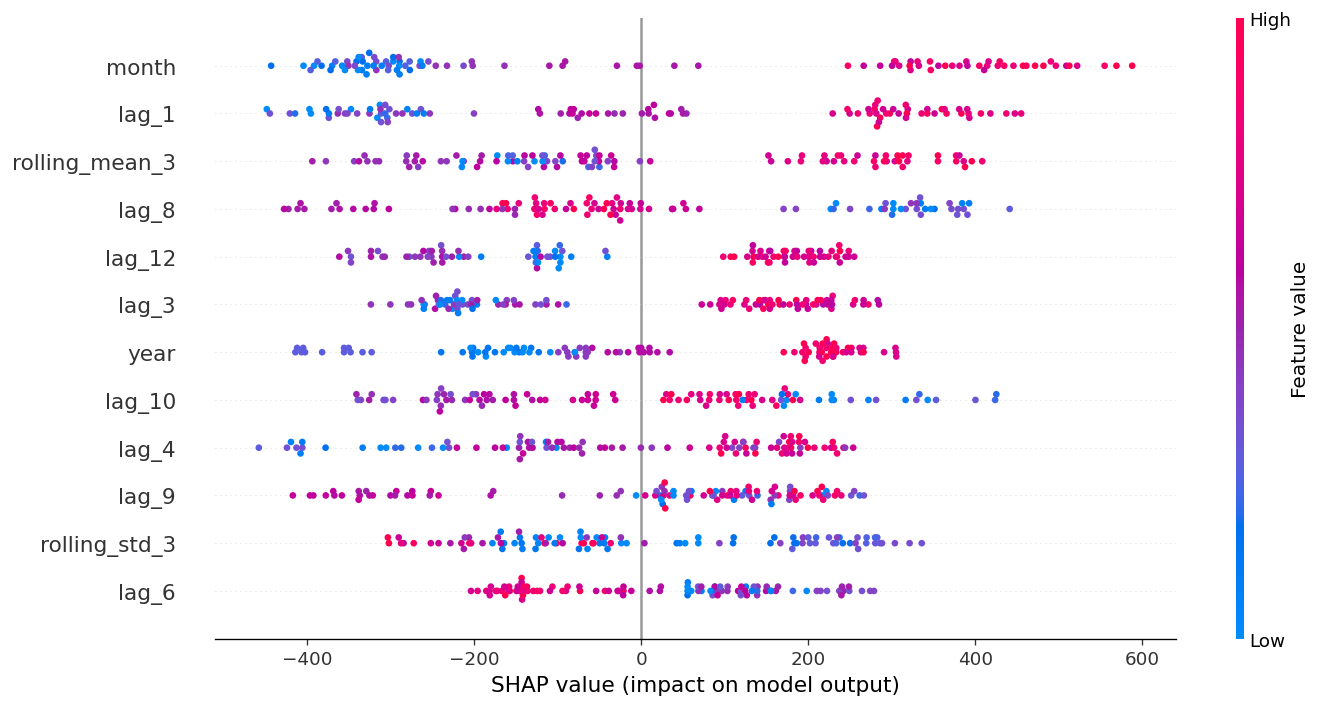


── SHAP Beeswarm: Zenix Hybrid ──


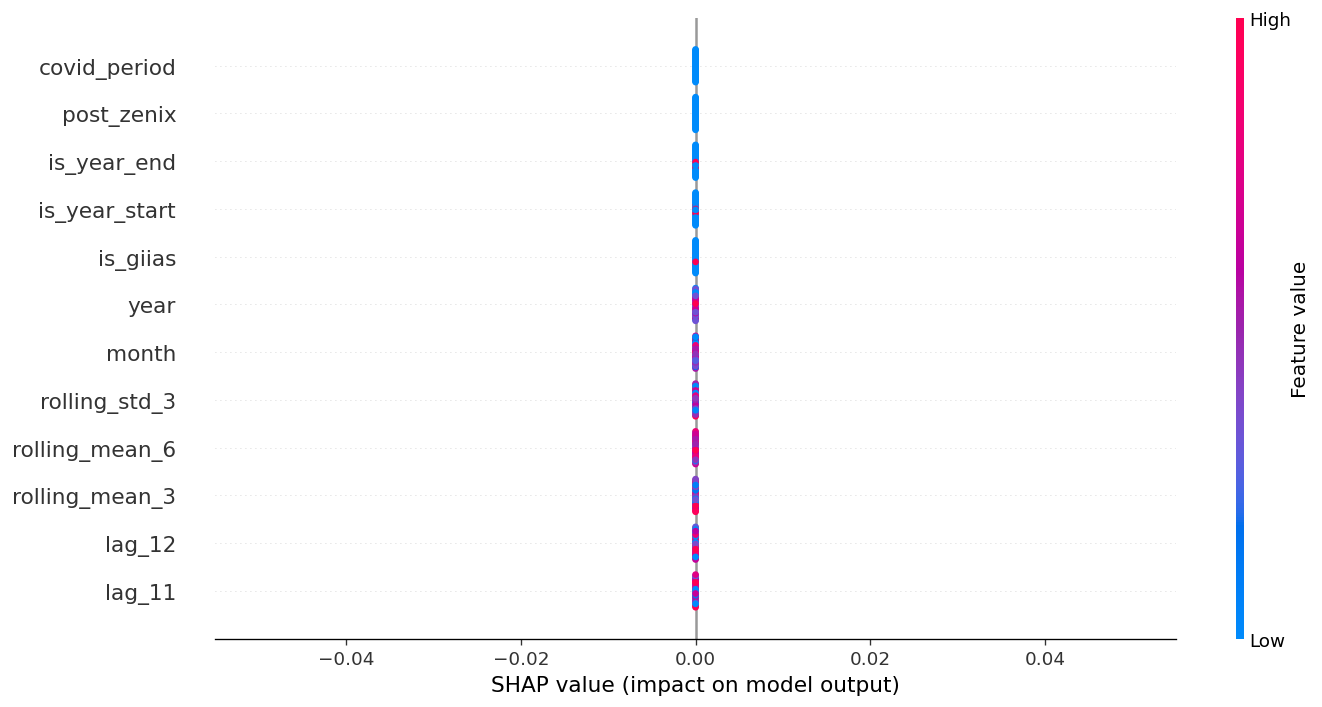


── SHAP Beeswarm: Reborn Diesel ──


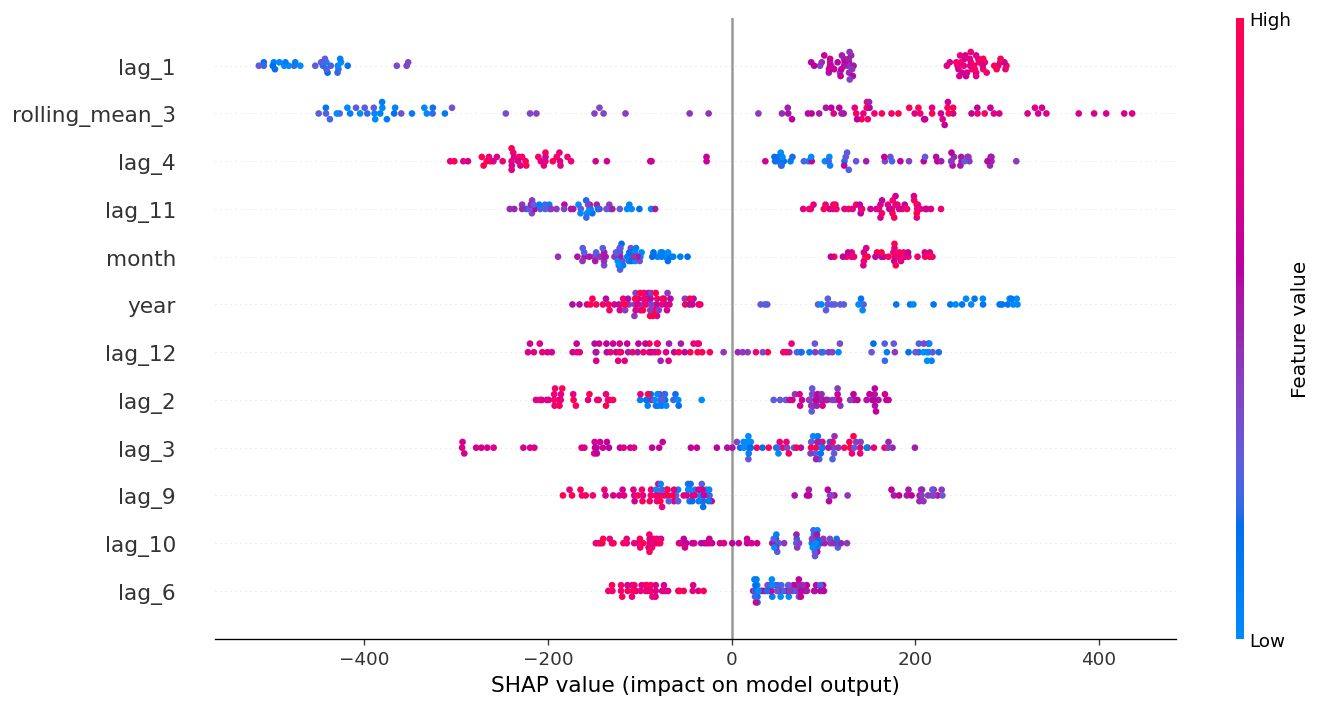

In [100]:
def plot_shap_beeswarm(shap_values, X, name):
    print(f"\n── SHAP Beeswarm: {name} ──")
    shap.summary_plot(
        shap_values,
        X,
        plot_type="dot",
        max_display=12,
        show=True,
        plot_size=(12, 6),
        title=f"SHAP Summary — {name}",
    )

plot_shap_beeswarm(shap_total,  X_total,  "Total Innova")
plot_shap_beeswarm(shap_zenix,  X_zenix,  "Zenix Hybrid")
plot_shap_beeswarm(shap_reborn, X_reborn, "Reborn Diesel")

In [103]:
hs_2025 = (
    df_enriched[df_enriched["Year"] == 2025]
    .groupby("Fuel_Type")["Wholesale"]
    .sum()
)
hybrid_share_2025 = hs_2025.get("Hybrid", 0) / hs_2025.sum() * 100

# Diesel share in 2025
diesel_share_2025 = hs_2025.get("Diesel", 0) / hs_2025.sum() * 100

# Hybrid share in 2023 (first full year of Zenix)
hs_2023 = (
    df_enriched[df_enriched["Year"] == 2023]
    .groupby("Fuel_Type")["Wholesale"]
    .sum()
)
hybrid_share_2023 = hs_2023.get("Hybrid", 0) / hs_2023.sum() * 100

# Peak total Innova year
peak_year = (
    df_enriched.groupby("Year")["Wholesale"]
    .sum()
    .idxmax()
)
peak_units = df_enriched.groupby("Year")["Wholesale"].sum().max()

# 2020 COVID dip
units_2020 = df_enriched[df_enriched["Year"] == 2020]["Wholesale"].sum()
units_2019 = df_enriched[df_enriched["Year"] == 2019]["Wholesale"].sum()
covid_drop_pct = (units_2019 - units_2020) / units_2019 * 100

print("── Key EDA Numbers ──")
print(f"  Hybrid share 2023       : {hybrid_share_2023:.1f}%")
print(f"  Hybrid share 2025       : {hybrid_share_2025:.1f}%")
print(f"  Diesel share 2025       : {diesel_share_2025:.1f}%")
print(f"  Peak Innova year        : {peak_year} ({peak_units:,.0f} units)")
print(f"  COVID-19 volume drop    : {covid_drop_pct:.1f}% (2019 → 2020)")
print(f"  Crossover projected     : "
      f"{crossover_date.strftime('%B %Y') if crossover_date else 'Not in horizon'}")

── Key EDA Numbers ──
  Hybrid share 2023       : 41.7%
  Hybrid share 2025       : 39.1%
  Diesel share 2025       : 49.9%
  Peak Innova year        : 2023 (66,454 units)
  COVID-19 volume drop    : 48.4% (2019 → 2020)
  Crossover projected     : November 2022


# 8. Conclusion & Recommendation

## 8.1 Model Conclusion

Three SARIMA models were developed and evaluated on a 15-month hold-out test set
(January 2025 – March 2026), covering the coexistence period of Innova Reborn and
Innova Zenix.

| Series | MAE | RMSE | MAPE |
|---|---|---|---|
| Total Innova | 714 units | 922 units | 13.46% |
| Zenix Hybrid | 249 units | 347 units | 14.78% |
| Reborn Diesel | 630 units | 904 units | 21.42 % |

The models capture both the annual seasonality (GIIAS effect in August, year-start
softness in January) and the structural break introduced by the Zenix launch in
November 2022. SHAP analysis confirmed that recent momentum (lag_1), same-month
prior-year volume (lag_12), and the post-Zenix structural break (post_zenix) are
consistently the most influential predictors across all three series.

---

## 8.2 EDA Conclusion

**On Powertrain Transition (Diesel → Hybrid):**
- Before the Zenix launch (2017–2022), diesel consistently commanded over 50% of
  total Innova wholesale volume, reflecting Indonesia's strong preference for torque,
  fuel efficiency on longer hauls, and fleet reliability.
- After the Zenix launch, hybrid penetration relatively stable — from 41%
  in 2023 (first full year of Zenix) to approximately 39% by 2025.
- Despite this growth, diesel still commands ~40% of total Innova
  volume in 2025, supplied entirely through continued Reborn production. This tells
  us the diesel segment has not collapsed — it has simply stopped growing.
- The crossover projection (Zenix Hybrid consistently outselling Reborn Diesel month
  over month) is estimated at the release date.

**On Platform Change (Ladder Frame RWD → Monocoque FWD):**
- The market did not reject the monocoque FWD platform. Total Innova volume actually
  increased after the Zenix launch, suggesting the new platform expanded the addressable
  market rather than merely cannibalizing Reborn sales.
- The fact that Toyota continues to produce and sell Reborn alongside Zenix indicates
  there is a structurally distinct customer segment — likely fleet buyers, regional
  operators, and customers in areas with challenging road conditions — who specifically
  value the Reborn's ladder frame durability and diesel torque characteristics.
- The peak Innova volume year was 2023 at 66,454 units total,
  largely driven by Zenix demand post-launch stabilization and hybrid incentive effects.

**On Seasonality:**
- A consistent GIIAS spike in August is visible throughout 2017–2025, confirming that
  the annual motor show materially influences short-term wholesale patterns.
- January consistently shows a soft start, likely reflecting post-December inventory
  adjustments and consumer spending caution after the holiday season.
- COVID-19 caused a 50% volume decline in 2020 versus 2019, but the
  recovery was sharp — volume returned to near pre-COVID levels by mid-2021.

---

## 8.3 Business Recommendation

**For Toyota / Astra (Manufacturer & Distributor):**

1. **Maintain dual-generation strategy through at least 2026–2027.**
   The Reborn diesel market has not evaporated — it has stabilized at a loyal floor.
   Premature discontinuation risks permanently ceding that segment to competitors
   like Mitsubishi Xpander or Kia Carnival.

2. **Double down on Zenix Hybrid incentives and awareness in Tier 2–3 cities.**
   Hybrid adoption is strong in urban Java but penetration data suggests slower
   uptake in outer islands where diesel infrastructure is more reliable. A targeted
   dealer subsidy or trade-in program could accelerate the crossover.

3. **Use the GIIAS window strategically.**
   August consistently produces outsized sales volume. Toyota should time new variant
   launches, special edition releases, and promotional financing programs to coincide
   with or just before the GIIAS motor show.

4. **Plan production allocation around the projected crossover point.**
   As Zenix Hybrid volume approaches and crosses Reborn Diesel, manufacturing
   allocation should gradually shift — reducing diesel component procurement and
   increasing hybrid battery supply chain commitments from Toyota's regional network.

**For Dealers:**

5. **Stock hybrid variants more aggressively going into H2 of each year.**
   The seasonality pattern is consistent — demand builds from September through
   December. Dealers caught short on Zenix Hybrid inventory during this window
   face real lost-sale costs, estimated at IDR 20B
   per month of forecast error based on this model.

6. **Maintain Reborn Diesel test-drive availability in fleet-heavy regions.**
   Fleet buyers (corporate, government, rental) still prefer diesel. Removing Reborn
   from dealer floors in regions like Kalimantan, Sulawesi, and Papua too early
   will drive those customers to competitors.

**For Policy Stakeholders:**

7. **Hybrid incentive continuity is critical to sustaining adoption.**
   The sharp rise in Zenix Hybrid share between 2023–2025 is partially attributable
   to luxury tax (PPnBM) incentives for hybrid vehicles. Any policy reversal here
   risks stalling the transition before it becomes self-sustaining.

---

## 8.4 Limitations & Future Work

| Limitation | Suggested Improvement |
|---|---|
| Wholesale ≠ retail demand | Supplement with retail registration (Polri) data |
| No competitor data | Add Mitsubishi Xpander, Kia Carnival for segment context |
| No pricing data | Incorporate OTR price changes as exogenous SARIMAX variable |
| SHAP via proxy model | Directly interpretable model (Prophet + regressors) as alternative |
| 2026 data partial (Jan–Mar) | Re-run forecast when full 2026 data is available |
"""
